In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
import numpy as np
import matplotlib.pyplot as plt

import utils.helpers as hlp 
from utils.evaluation import AccuracyEvaluator
from samplers.linear_models import BayesianRegression

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Math

# Sampling with the Wisconsin Breast Cancer data  
## Load and Preprocess the data

In [2]:
seed=42
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]
y_train = np.asarray(y_train, dtype=int)
y_test = np.asarray(y_test, dtype=int)

print(f"Training data contains {X_train.shape[0]} observations\n" 
      f"Test data contains {X_test.shape[0]} observations\n"
      f"Dimension: {X_train.shape[1]}")

Training data contains 455 observations
Test data contains 114 observations
Dimension: 31


## Set the boundary condition to select from $\ell_2$-ball prior

In [3]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train, y_train)
beta_hat = clf.coef_.flatten()
lp = 2 
s = 0.8 * np.linalg.norm(beta_hat, ord=lp)
display(
    Math(
        rf'\|\hat{{\beta}}\|_{lp}={np.linalg.norm(beta_hat, ord=lp):.4f}, '
        rf'\quad s={s:.4f}')
)

<IPython.core.display.Math object>

In [4]:
def get_the_chain(
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    N=100, batch_size=10, eta=5e-4, gamma=1e-3, 
    s=s, lp=lp, n_iteration=200, size_w=20,
    nets = ("fcn", "cn", "sn", "fdn"),
    seed=seed, type='logistic',
    figsize=(32, 16)
):
    fig, axes = plt.subplots(2, 4, figsize=figsize, sharey=False)
    network_names = ["Fully Connected", "Circular", "Star", "Disconnected"]
    
    mysgld_model = BayesianRegression(
        X=X_train, y=y_train, type=type,
        N=N, eta=eta, gamma=gamma,
        n_iteration=n_iteration,
        batch_size=batch_size, seed=seed
    )
    mysgld_chain = mysgld_model.sample_parameters(
        method='mysgld'
    )
    mysgld_evaluator = AccuracyEvaluator(mysgld_chain)
    mysgld_acc, mysgld_std = mysgld_evaluator.compute_accuracy(
        X=X_test, y=y_test
    )
    
    for j, (net, name) in enumerate(zip(nets, network_names)):
        ax_top = axes[0, j]
        ax_bottom = axes[1, j]
        dpsgld_model = BayesianRegression(
            X=X_train, y=y_train, N=N,
            batch_size=batch_size, eta=eta,
            gamma=gamma, s=s, lp=lp,
            n_iteration=n_iteration,
            size_w=size_w, net=net,
            type=type
        )
        history_all, beta_mean_all = dpsgld_model.sample_parameters(
            method='dpsgld'
        )
        dpsgld_agent_evaluator = AccuracyEvaluator(history_all)
        dpsgld_agent_acc, dpsgld_agent_std = dpsgld_agent_evaluator.compute_accuracy(
            X=X_test, y=y_test
        )
        agent = dpsgld_agent_evaluator.get_selected_agent()
        
        ax_top.plot(dpsgld_agent_acc, 'g-', linewidth=3)
        ax_top.fill_between(
            range(len(dpsgld_agent_acc)), dpsgld_agent_acc - dpsgld_agent_std,
            dpsgld_agent_acc + dpsgld_agent_std, alpha=0.3, color='green' 
        )
        ax_top.plot(mysgld_acc, 'r-', linewidth=3)
        ax_top.fill_between(
            range(len(mysgld_acc)), mysgld_acc - mysgld_std,
            mysgld_acc + mysgld_std, alpha=0.3, color='red'
        )
        ax_top.set_title(f"{name}\nAgent {agent} vs MYSGLD", fontsize=30)
        ax_top.tick_params(axis="both", labelsize=28)
        ax_top.set_xlabel("Iteration", fontsize=28)
        ax_top.set_ylabel("Accuracy", fontsize=28)
        
        
        dpsgld_mean_evaluator = AccuracyEvaluator(beta_mean_all)
        dpsgld_mean_acc, dpsgld_mean_std = dpsgld_mean_evaluator.compute_accuracy(
            X=X_test, y=y_test
        )
        ax_bottom.plot(dpsgld_mean_acc, 'b-', linewidth=3)
        ax_bottom.fill_between(
            range(len(dpsgld_mean_acc)), dpsgld_mean_acc - dpsgld_mean_std,
            dpsgld_mean_acc + dpsgld_mean_std, alpha=0.3, color='blue'
        )
        ax_bottom.plot(mysgld_acc, 'r-', linewidth=3)
        ax_bottom.fill_between(
            range(len(mysgld_acc)), mysgld_acc - mysgld_std,
            mysgld_acc + mysgld_std, alpha=0.3, color='red'
        )
        ax_bottom.set_title(f"{name}\nMean vs MYSGLD", fontsize=30)
        ax_bottom.tick_params(axis="both", labelsize=28)
        ax_bottom.set_xlabel("Iteration", fontsize=28)
        ax_bottom.set_ylabel("Accuracy", fontsize=28)
    plt.tight_layout()
    plt.savefig('images/bcan.png')
    plt.show()

100%|██████████| 350/350 [00:03<00:00, 98.90it/s] 


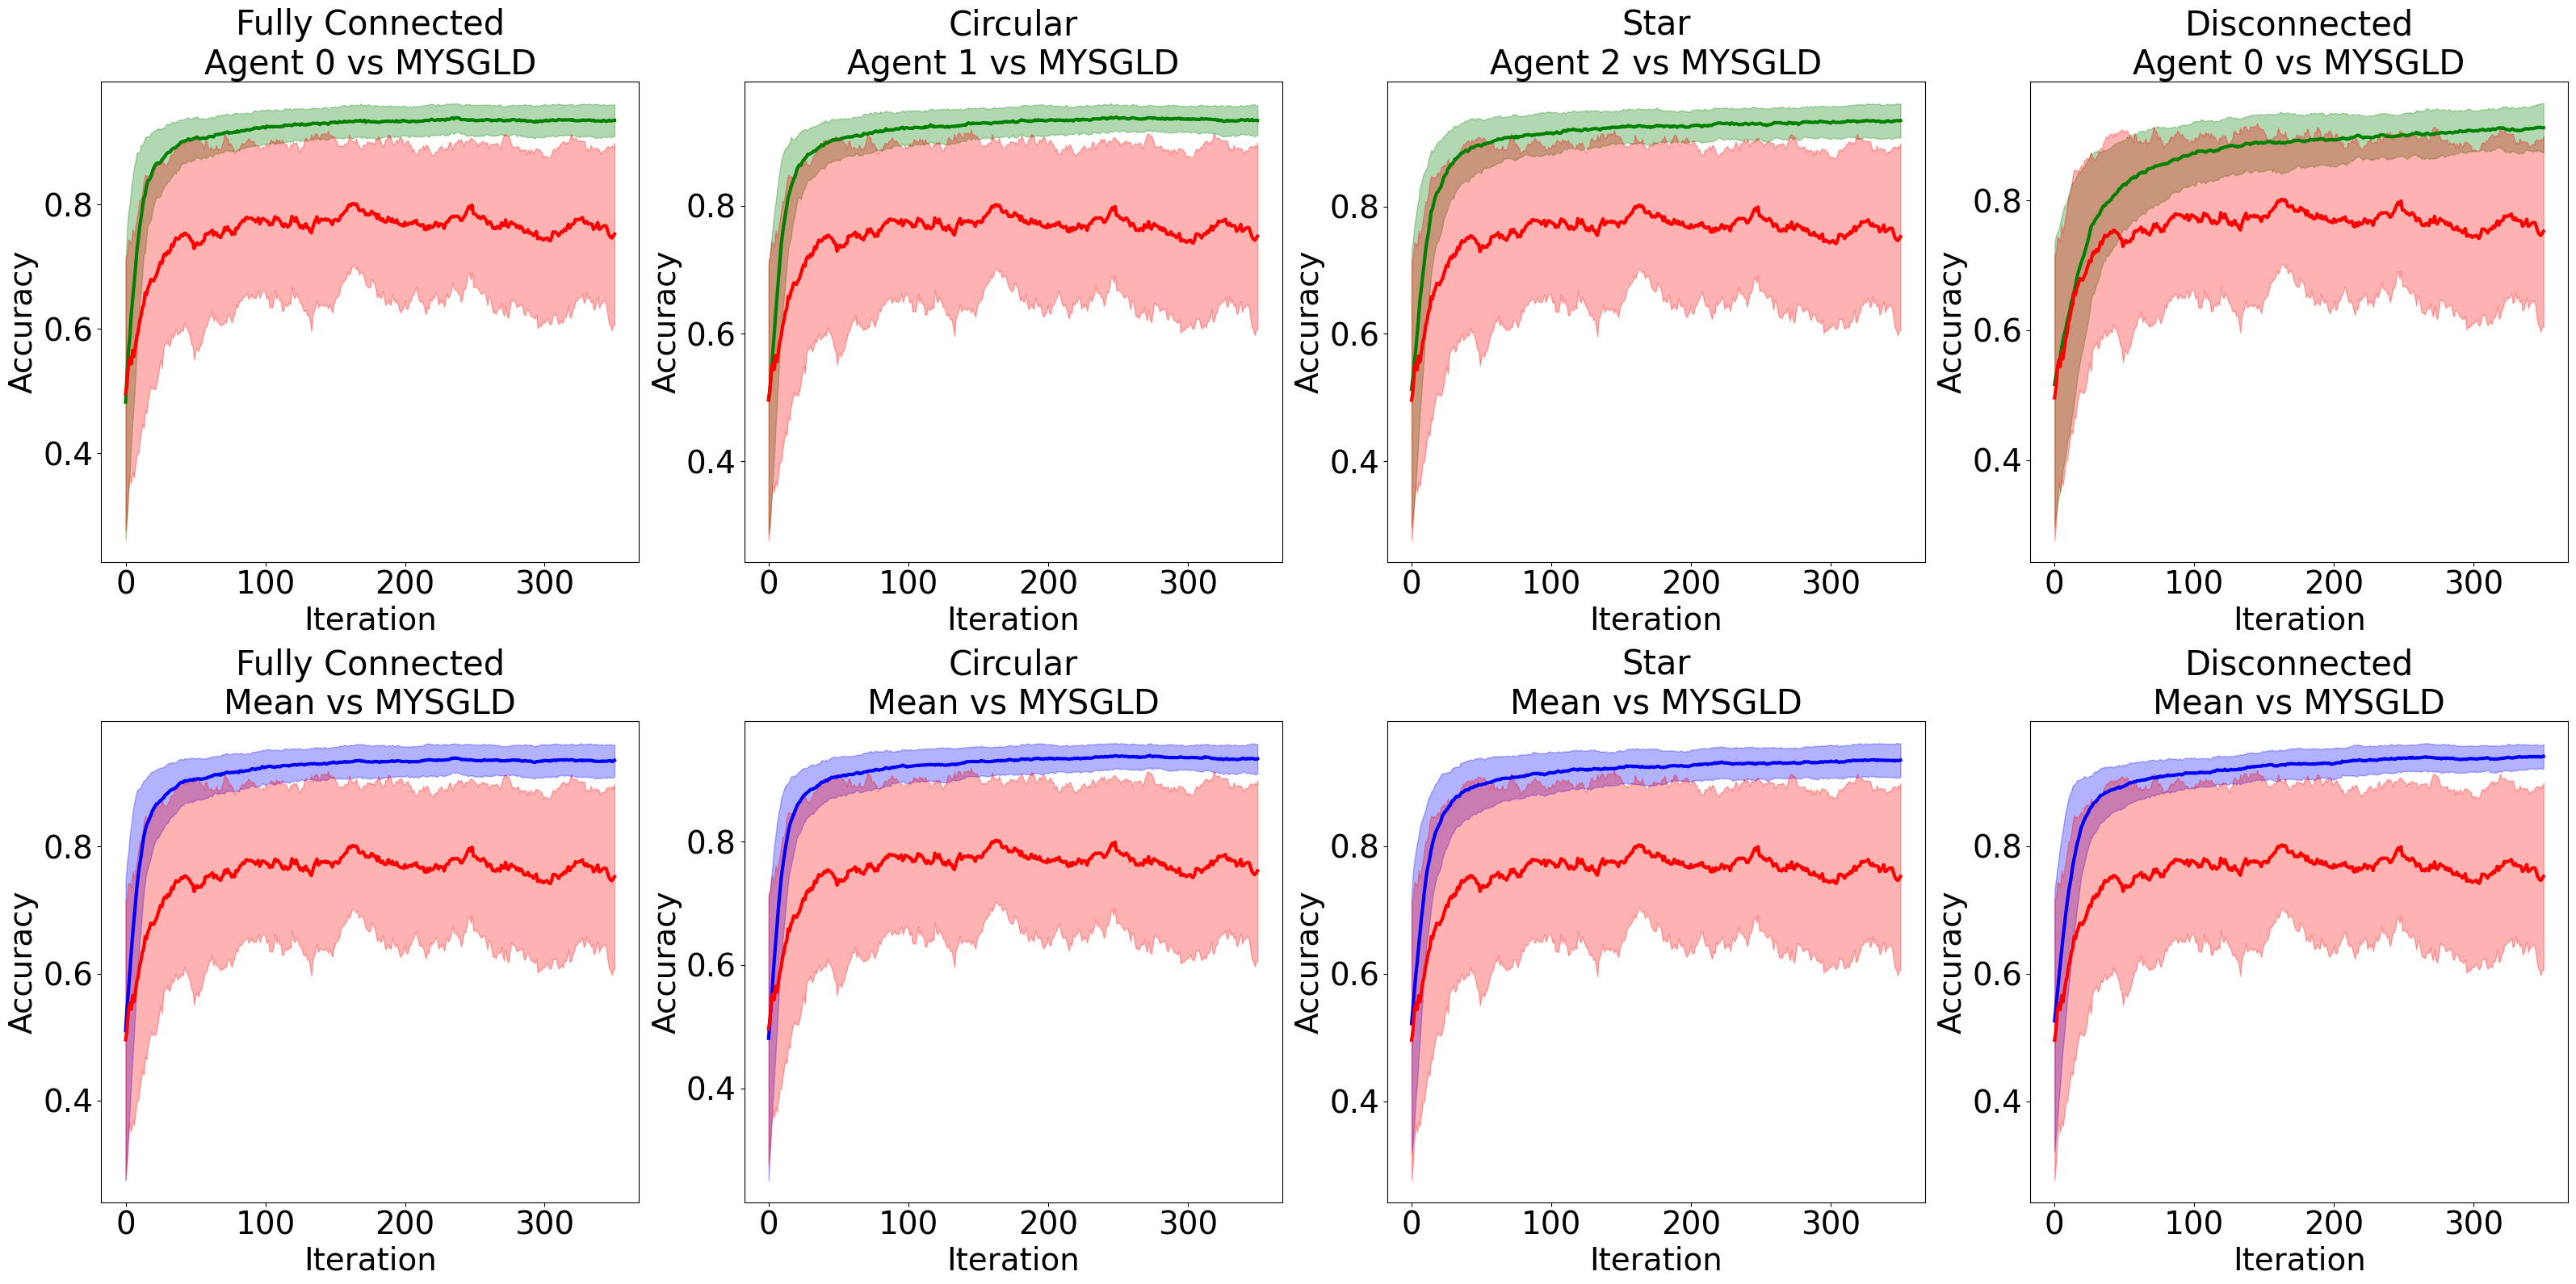

In [8]:
get_the_chain(size_w=4, n_iteration=350, gamma=1e-2, batch_size=10)